# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [49]:
STUDENT_NAME = "Nguyen Minh Tri"  # TODO: Họ và tên
STUDENT_ID = "2413637"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Nguyen Minh Tri (2413637)


In [51]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: C:\Users\TRI\Music\numpy-pandas-eda-hw\Data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [54]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [56]:
# TODO N1
# shifted_logits = ...
# exp_logits = ...
# class_probabilities = ...
# predicted_classes = ...
# confidence_scores = ...

# TODO N1
# Trừ max của từng hàng (axis=1) và giữ nguyên chiều để broadcast
shifted_logits = logits - np.max(logits, axis=1, keepdims=True)
exp_logits = np.exp(shifted_logits)

# Tính tổng của từng hàng rồi chia để ra xác suất
class_probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

# Lấy index của class có xác suất lớn nhất
predicted_classes = np.argmax(class_probabilities, axis=1)

# Lấy xác suất lớn nhất
confidence_scores = np.max(class_probabilities, axis=1)

In [58]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [61]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [63]:
# TODO N2
# train_feature_mean = ...
# train_feature_std = ...
# X_train_scaled = ...
# X_val_scaled = ...

# TODO N2
train_feature_mean = np.mean(X_train, axis=0)
train_feature_std = np.std(X_train, axis=0)

X_train_scaled = (X_train - train_feature_mean) / train_feature_std
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

In [65]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [68]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [70]:
# TODO N3
correct_mask = (predicted_classes == true_labels)
high_confidence_mask = (confidence_scores >= confidence_threshold)

# Review nếu KHÔNG đúng HOẶC KHÔNG tự tin
review_mask = ~correct_mask | ~high_confidence_mask
review_indices = np.where(review_mask)[0]


## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [73]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [75]:
# TODO N4
# Chuyển sang float32 trong [0, 1]
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0

# Tạo bản copy độc lập rồi flip ngang (theo chiều width, axis=2)
augmented_batch = normalized_batch.copy()
augmented_batch = augmented_batch[:, :, ::-1, :].copy()

# Chỉnh sửa augmented_batch không ảnh hưởng normalized_batch vì đã copy() bộ nhớ độc lập
augmented_batch[0, 0, 0, 0] = 1.0


# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

1. Mỗi dòng đại diện cho một mẫu xe (một phiên bản xe cụ thể) trong bộ dữ liệu Automobile Imports năm 1985.
2. Ký hiệu missing value trong CSV là dấu `?`.
3. `symboling` là mức đánh giá rủi ro bảo hiểm do các nhà bảo hiểm gán cho xe, có giá trị từ -3 (an toàn hơn dự đoán, rủi ro thấp) đến 3 (rủi ro cao hơn dự đoán so với giá xe).

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [80]:
# TODO D1
raw_df = pd.read_csv(DATA_PATH, dtype=str)
raw_shape = raw_df.shape
raw_missing_marker_count = int((raw_df == '?').sum().sum())

print("raw_shape:", raw_shape)
print("raw_missing_marker_count:", raw_missing_marker_count)
raw_df.head()


raw_shape: (205, 26)
raw_missing_marker_count: 59


,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.60,...,130,mpfi,3.47,2.68,9.00,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.60,...,130,mpfi,3.47,2.68,9.00,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.50,...,152,mpfi,2.68,3.47,9.00,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.80,...,109,mpfi,3.19,3.40,10.00,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.40,...,136,mpfi,3.19,3.40,8.00,115,5500,18,22,17450


## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [83]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [85]:
# TODO D2
df_clean = raw_df.replace('?', np.nan)

for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column], errors='raise')

missing_by_column = df_clean.isna().sum().sort_values(ascending=False)
print(missing_by_column[missing_by_column > 0])


normalized_losses    41
price                 4
stroke                4
bore                  4
peak_rpm              2
num_doors             2
horsepower            2
dtype: int64


### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

Không nên fill tất cả các cột numeric bằng cùng một giá trị (ví dụ 0 hoặc median chung) vì mỗi cột có đơn vị và phân phối khác nhau (ví dụ `bore` tính bằng inches còn `horsepower` tính bằng hp); dùng chung một giá trị sẽ làm sai lệch thống kê và mối quan hệ giữa các biến. Với `price`, vì đây là biến mục tiêu chính của phân tích EDA và số dòng thiếu chỉ 4/205 (rất nhỏ), nên drop các dòng thiếu `price` hợp lý hơn là fill, để tránh đưa vào các giá trị nhân tạo có thể làm sai lệch phân phối giá hay tương quan với các biến khác. `normalized_losses` thiếu tới 41/205 dòng (khoảng 20%), đây là tỷ lệ thiếu lớn nhất trong dataset; nếu dùng cột này để phân tích cần cẩn trọng vì mẫu con có giá trị `normalized_losses` có thể không đại diện đầy đủ cho toàn bộ dataset, và việc fill hay drop đều ảnh hưởng đáng kể đến kích thước và độ tin cậy của phân tích liên quan đến cột này.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [92]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [94]:
# TODO D3
analysis_df = df_clean.dropna(subset=AUTO_FEATURES).reset_index(drop=True)

X_auto = analysis_df[AUTO_FEATURES].to_numpy(dtype=np.float64)
auto_feature_mean = X_auto.mean(axis=0)
auto_feature_std = X_auto.std(axis=0)
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

print("analysis_df shape:", analysis_df.shape)
print("auto_feature_mean:", auto_feature_mean)
print("auto_feature_std:", auto_feature_std)


analysis_df shape: (199, 26)
auto_feature_mean: [ 2556.03015075   126.8241206    103.39698492    25.20100503
    30.68341709 13243.4321608 ]
auto_feature_std: [5.18547730e+02 4.16478926e+01 3.74593675e+01 6.43559503e+00
 6.83217899e+00 7.95863536e+03]


## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [97]:
# TODO D4
price_index = AUTO_FEATURES.index('price')
price_z = X_auto_scaled[:, price_index]
price_outlier_mask = np.abs(price_z) > 2
price_outliers = analysis_df.loc[price_outlier_mask, ['make', 'body_style', 'price']]

print("So luong outlier:", price_outlier_mask.sum())
price_outliers


So luong outlier: 14


,make,body_style,price
14,bmw,sedan,30760.0
15,bmw,sedan,41315.0
16,bmw,sedan,36880.0
44,jaguar,sedan,32250.0
45,jaguar,sedan,35550.0
46,jaguar,sedan,36000.0
67,mercedes-benz,sedan,31600.0
68,mercedes-benz,sedan,34184.0
69,mercedes-benz,convertible,35056.0
70,mercedes-benz,sedan,40960.0


## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [100]:
# TODO D5
engine_index = AUTO_FEATURES.index('engine_size')
engine_price_corr = np.corrcoef(X_auto[:, engine_index], X_auto[:, price_index])[0, 1]

price_by_body_style = df_clean.groupby('body_style')['price'].mean().sort_index()

print("engine_price_corr:", engine_price_corr)
price_by_body_style


engine_price_corr: 0.8738869517981518


body_style
convertible    21890.500000
hardtop        22208.500000
hatchback       9957.441176
sedan          14459.755319
wagon          12371.960000
Name: price, dtype: float64

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

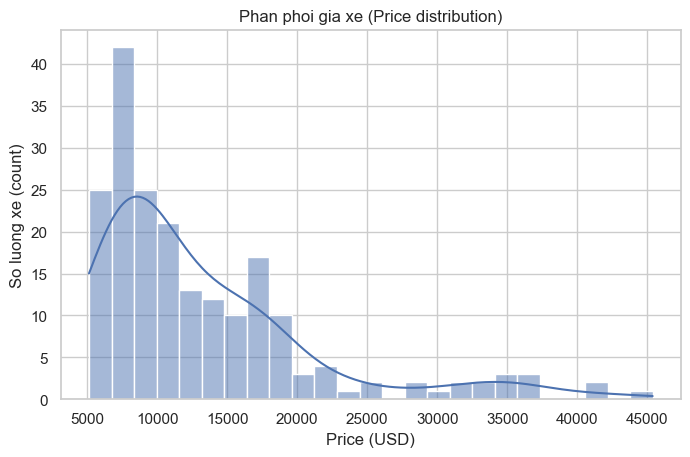

In [104]:
# TODO M2.1: histogram/KDE của price
fig, ax = plt.subplots()
sns.histplot(df_clean['price'].dropna(), kde=True, bins=25, ax=ax, color="#4C72B0")
ax.set_title("Phan phoi gia xe (Price distribution)")
ax.set_xlabel("Price (USD)")
ax.set_ylabel("So luong xe (count)")
plt.show()


**Nhận xét:** Phân phối `price` lệch phải (right-skewed) rõ rệt: phần lớn xe tập trung ở khoảng 5,000-16,500 USD (median khoảng 10,295 USD) trong khi một số ít xe hạng sang (BMW, Mercedes-Benz, Jaguar, Porsche) kéo giá lên tới hơn 40,000 USD, tạo đuôi dài về phía bên phải.

## M2.2 Dataset có cân bằng theo body style không?

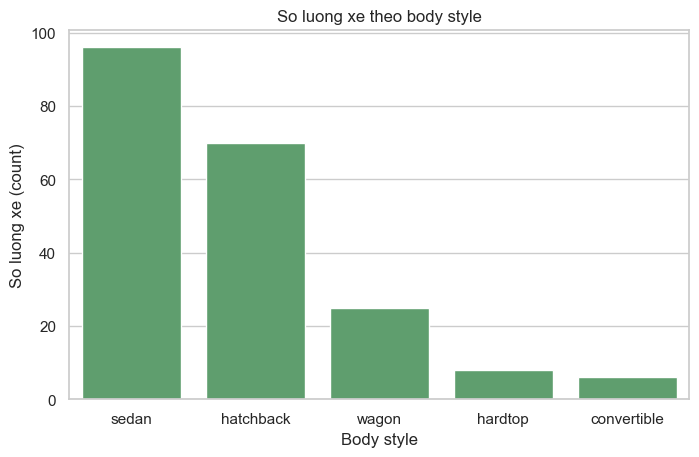

In [108]:
# TODO M2.2: countplot của body_style
fig, ax = plt.subplots()
order = df_clean['body_style'].value_counts().index
sns.countplot(data=df_clean, x='body_style', order=order, ax=ax, color="#55A868")
ax.set_title("So luong xe theo body style")
ax.set_xlabel("Body style")
ax.set_ylabel("So luong xe (count)")
plt.show()


**Nhận xét:** Dataset không cân bằng theo `body_style`: `sedan` (96 xe) và `hatchback` (70 xe) chiếm phần lớn, trong khi `convertible` (6 xe) và `hardtop` (8 xe) rất ít, nên các thống kê theo nhóm hiếm (như giá trung bình convertible) kém tin cậy hơn.

## M2.3 Price khác nhau theo body style ra sao?

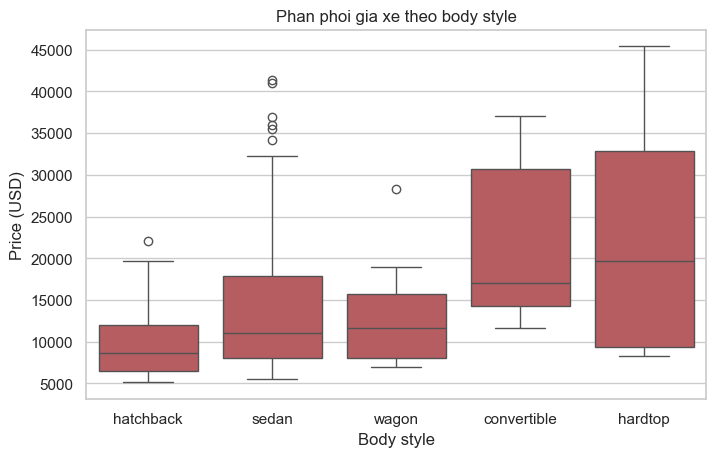

In [112]:
# TODO M2.3: boxplot price theo body_style
fig, ax = plt.subplots()
order = df_clean.groupby('body_style')['price'].median().sort_values().index
sns.boxplot(data=df_clean, x='body_style', y='price', order=order, ax=ax, color="#C44E52")
ax.set_title("Phan phoi gia xe theo body style")
ax.set_xlabel("Body style")
ax.set_ylabel("Price (USD)")
plt.show()


**Nhận xét:** `hardtop` và `convertible` có giá trung bình cao nhất (khoảng 22,200 USD và 21,900 USD) và phân tán rộng, trong khi `hatchback` có giá thấp nhất (trung bình khoảng 9,960 USD) và ít outlier hơn.

## M2.4 Engine size liên quan thế nào tới price?

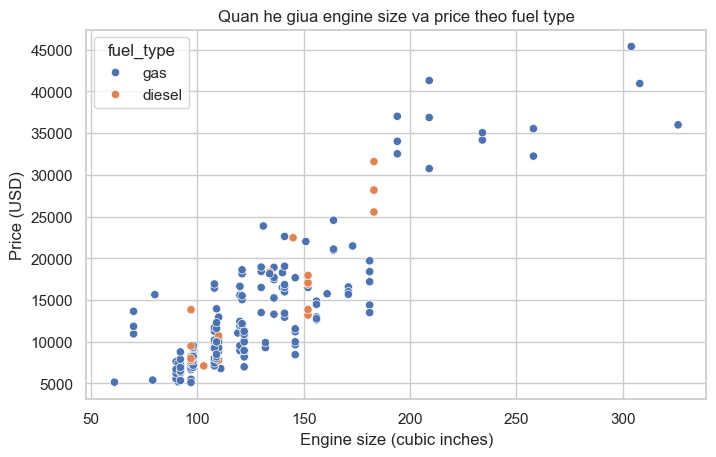

In [116]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
fig, ax = plt.subplots()
sns.scatterplot(data=df_clean, x='engine_size', y='price', hue='fuel_type', ax=ax)
ax.set_title("Quan he giua engine size va price theo fuel type")
ax.set_xlabel("Engine size (cubic inches)")
ax.set_ylabel("Price (USD)")
plt.show()


**Nhận xét:** `engine_size` và `price` có tương quan dương khá mạnh (Pearson r xấp xỉ 0.87): xe có dung tích động cơ lớn hơn thường có giá cao hơn, và xu hướng này xuất hiện ở cả xe chạy gas lẫn diesel.

## M2.5 Các feature numeric tương quan ra sao?

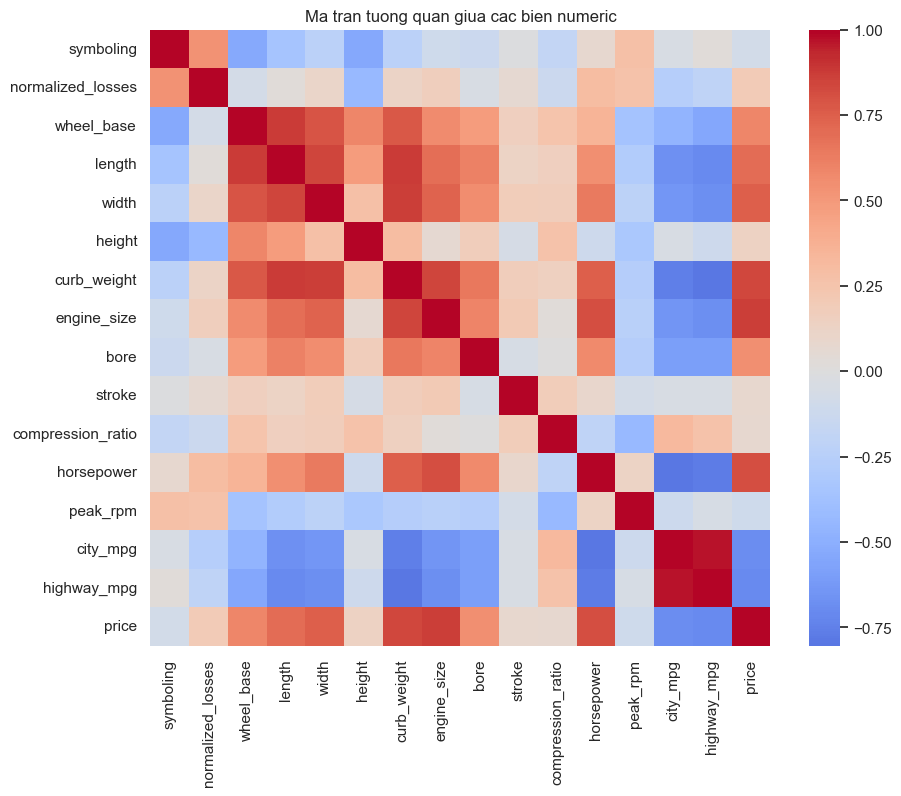

In [120]:
# TODO M2.5: correlation heatmap
numeric_df = df_clean.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False, ax=ax)
ax.set_title("Ma tran tuong quan giua cac bien numeric")
plt.show()


**Nhận xét:** `price` tương quan dương mạnh nhất với `engine_size`, `curb_weight` và `horsepower` (r xấp xỉ 0.81-0.87), và tương quan âm với `city_mpg`/`highway_mpg` (r xấp xỉ -0.69 và -0.70), phản ánh việc xe càng mạnh và nặng thì càng tốn nhiên liệu và đắt hơn.

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

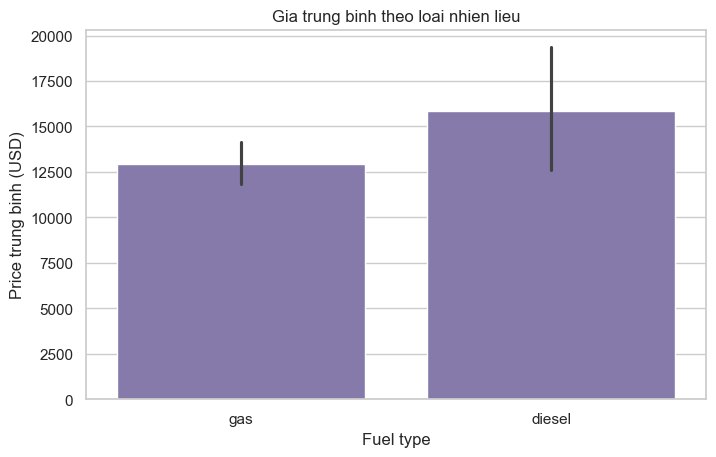

In [124]:
# TODO M2.6: bieu do tu chon
# Cau hoi: Xe dung nhien lieu diesel co dat hon xe dung gas khong?
fig, ax = plt.subplots()
sns.barplot(data=df_clean, x='fuel_type', y='price', errorbar=('ci', 95), ax=ax, color="#8172B2")
ax.set_title("Gia trung binh theo loai nhien lieu")
ax.set_xlabel("Fuel type")
ax.set_ylabel("Price trung binh (USD)")
plt.show()


**Nhận xét:** Xe diesel có giá trung bình cao hơn xe gas (khoảng 15,838 USD so với 12,916 USD), tuy nhiên số lượng xe diesel trong dataset khá ít nên khoảng tin cậy của ước lượng này khá rộng.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

Qua quá trình phân tích bộ dữ liệu Automobile, có thể rút ra một số phát hiện chính. Thứ nhất, phân phối giá xe (`price`) lệch phải rõ rệt, với trung vị khoảng 10,295 USD nhưng một nhóm nhỏ xe hạng sang (BMW, Mercedes-Benz, Jaguar, Porsche) có giá vượt 30,000-45,000 USD, tạo thành các outlier theo z-score. Thứ hai, `engine_size` và `curb_weight` là hai biến tương quan dương mạnh nhất với `price` (Pearson r lần lượt khoảng 0.87 và 0.83), cho thấy xe có động cơ lớn và nặng hơn thường đắt hơn. Thứ ba, `city_mpg` và `highway_mpg` tương quan âm khá mạnh với `price` (khoảng -0.69 và -0.70), phản ánh việc xe mạnh thường tốn nhiên liệu hơn. Thứ tư, dataset mất cân bằng theo `body_style`, với `sedan` và `hatchback` chiếm đa số còn `convertible` và `hardtop` rất ít mẫu. Thứ năm, xe diesel có giá trung bình cao hơn xe gas (khoảng 15,838 so với 12,916 USD).

Về hạn chế, dataset khá nhỏ (205 dòng) và có tỷ lệ thiếu dữ liệu đáng kể ở cột `normalized_losses` (khoảng 20%), làm giảm độ tin cậy của các phân tích liên quan đến cột này; ngoài ra, dữ liệu chỉ đại diện cho các mẫu xe nhập khẩu năm 1985 nên khó tổng quát hóa cho thị trường ô tô hiện nay.

Một ví dụ về correlation không đồng nghĩa causation: `engine_size` tương quan dương với `price`, nhưng không thể kết luận việc tăng dung tích động cơ trực tiếp gây ra giá xe cao hơn, vì cả hai đều có thể chịu ảnh hưởng chung từ yếu tố thứ ba như thương hiệu và phân khúc xe (xe hạng sang thường vừa có động cơ lớn vừa có giá cao do định vị thương hiệu, không chỉ vì kích thước động cơ).

Câu hỏi nên phân tích tiếp: Ảnh hưởng của `make` (thương hiệu) đến `price` sau khi đã kiểm soát các biến kỹ thuật như `engine_size` và `curb_weight` là như thế nào, tức là liệu thương hiệu có tạo ra chênh lệch giá đáng kể ngay cả khi các đặc tính kỹ thuật của xe là tương đương hay không?

## Tổng hợp

Tôi tên là nguyễn minh trí
